In [1]:
import os
import sys

# to setup import paths add project root dirs to sys.path
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
from baseVR.base_functionality import init_import_paths
init_import_paths()


In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# %matplotlib qt
# %matplotlib widget

from analytics_processing import analytics
import analytics_processing.analytics_constants as C
from CustomLogger import CustomLogger as Logger

from dashsrc.plot_components.plot_wrappers.data_selection import group_filter_data

from analytics_processing.modality_loading import session_modality_from_nas
from analytics_processing.sessions_from_nas_parsing import sessionlist_fullfnames_from_args
from analytics_processing.sessions_from_nas_parsing import fullfnames2snames


In [4]:
# ephys
# paradigm_ids = [0,1100]
# animal_ids = [10]
# session_ids = [0,1,2,3]

animal_ids = [6]
paradigm_ids = [1100]
session_ids = None

# width = 1400
# height = 1400
# group_by = None

# session_modality_from_nas

output_dir = "./outputs/experimental/"
data = {}
nas_dir = C.device_paths()[0]
Logger().init_logger(None, None, logging_level="INFO")

In [6]:
session_dirs = sessionlist_fullfnames_from_args(paradigm_ids, animal_ids, session_ids)[0]
for sd in session_dirs:
    print(sd)
session_names = fullfnames2snames(session_dirs)
for sn in session_names:
    print(sn)

# session_modality_from_nas(session_dirs[0], 'facecam_frames', stop=20)
# df = session_modality_from_nas(session_dirs[0], 'TrackKinematics')
# df

/mnt/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min/2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min.hdf5
/mnt/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-14_16-40_rYL006_P1100_LinearTrackStop_21min/2024-11-14_16-40_rYL006_P1100_LinearTrackStop_21min.hdf5
/mnt/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-15_15-48_rYL006_P1100_LinearTrackStop_35min/2024-11-15_15-48_rYL006_P1100_LinearTrackStop_35min.hdf5
/mnt/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-20_17-46_rYL006_P1100_LinearTrackStop_22min/2024-11-20_17-46_rYL006_P1100_LinearTrackStop_22min.hdf5
/mnt/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-21_17-22_rYL006_P1100_LinearTrackStop_25min/2024-11-21_17-22_rYL006_P1100_LinearTrackStop_25min.hdf5
/mnt/SpatialSequenceLearning/RUN_rYL006/rYL006_P1100/2024-11-22_16-01_rYL006_P1100_LinearTrackStop_24min/2024-11-22_16-01_rYL006_P1100_LinearTrackStop_24min.hdf5
/mnt/SpatialSequenceLearning

In [39]:
start_times = []
key = 'event'
for i in range(len(session_dirs)-20):
    session_dir = session_dirs[i]
    session_name = session_names[i]
    print(f"Processing session: {session_name}")
    unity = session_modality_from_nas(session_dirs[i], key, stop=20)
    if f'{key}_ephys_patched' not in unity.keys():
        print(f"Session {i}, {session_name} does not have {key}_ephys_patched")
        continue
    print(f"{key}_ephys_timestamp[0]: {unity[f'{key}_ephys_timestamp'][0]}")
    print(f"{key}_ephys_patched[sum]: {unity[f'{key}_ephys_patched'].sum()}")
    start_times.append(unity[f'{key}_ephys_timestamp'][0])
    print()
    print()
# plt.hist(start_times, bins=20)

reorder = [key+'_package_id',key+'_ephys_timestamp', key+'_ephys_patched', key+'_portenta_timestamp', key+'_pc_timestamp',]
unity = unity[reorder+[ col for col in unity.columns if col not in reorder]]
unity.drop(columns=['trial_id'], inplace=True)
unity = unity.astype({key+'_ephys_patched': bool})
unity = unity.rename(columns={key+'_ephys_patched': key+'_ephys_timestamp_patched'})
unity

Processing session: 2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min
Session 0, 2024-11-14_15-01_rYL006_P1100_LinearTrackStop_30min does not have event_ephys_patched
Processing session: 2024-11-14_16-40_rYL006_P1100_LinearTrackStop_21min
event_ephys_timestamp[0]: 12238100.0
event_ephys_patched[sum]: 1.0


Processing session: 2024-11-15_15-48_rYL006_P1100_LinearTrackStop_35min
event_ephys_timestamp[0]: 1846400.0
event_ephys_patched[sum]: 0.0


Processing session: 2024-11-20_17-46_rYL006_P1100_LinearTrackStop_22min
event_ephys_timestamp[0]: 8312600.0
event_ephys_patched[sum]: 0.0


Processing session: 2024-11-21_17-22_rYL006_P1100_LinearTrackStop_25min
event_ephys_timestamp[0]: 7852750.0
event_ephys_patched[sum]: 0.0


Processing session: 2024-11-22_16-01_rYL006_P1100_LinearTrackStop_24min
Session 5, 2024-11-22_16-01_rYL006_P1100_LinearTrackStop_24min does not have event_ephys_patched
Processing session: 2024-11-25_16-25_rYL006_P1100_LinearTrackStop_18min
event_ephys_timestamp[0]: 819

,event_package_id,event_ephys_timestamp,event_ephys_timestamp_patched,event_portenta_timestamp,event_pc_timestamp,event_value,event_name
0,435488,2061150.0,False,1323532858,1733331974535240,-6197,L
1,435489,5157950.0,False,1326624806,1733331977627201,-1376,L
2,435490,9018650.0,False,1330484781,1733331981487214,-684,L
3,435491,9020250.0,False,1330487106,1733331981489540,-1383,L
4,435492,9023250.0,False,1330491465,1733331981493884,-2741,L
5,435493,9035150.0,False,1330502671,1733331981505095,-2049,L
6,435494,9038150.0,False,1330504306,1733331981506740,-687,L
7,2063,10053950.0,False,1331520117,1733331982522563,250,S
8,435495,10081050.0,False,1331552009,1733331982554462,-5502,L
9,435496,10210000.0,False,1331676824,1733331982679261,-1376,L


In [5]:
framew_beh = analytics.get_analytics('BehaviorFramewise', animal_ids=[6], paradigm_ids=[1100])
# framew_beh.index = framew_beh.droplevel(['animal_id', 'entry_id'])
# framew_beh

/home/vrmaster/Projects/VirtualReality/analysisVR/analytics_processing/analytics.py:605: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  aggr = pd.concat(aggr)
/home/vrmaster/Projects/VirtualReality/analysisVR/analytics_processing/analytics.py:605: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  aggr = pd.concat(aggr)
/home/vrmaster/Projects/VirtualReality/analysisVR/analytics_processing/analytics.py:605: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecat

In [6]:
s_id = 0
framew_beh.columns

Index(['frame_id', 'frame_pc_timestamp', 'frame_position', 'frame_state',
       'ballvelocity_first_package', 'ballvelocity_last_package',
       'frame_ephys_timestamp', 'trial_id', 'frame_ephys_patched', 'fps',
       ...
       'trackzone_reward2_exit_ephys_t', 'trackzone_reward2_min_velocity',
       'trackzone_reward2_staytime', 'facecam_image_pc_timestamp',
       'trial_start_ephys_patched', 'trial_end_ephys_patched',
       'multi_reward_requires_stop', 'flip_Cue1R1_Cue2R2', 'prob_cue1_trial',
       'movement_gain_scaler'],
      dtype='object', length=135)

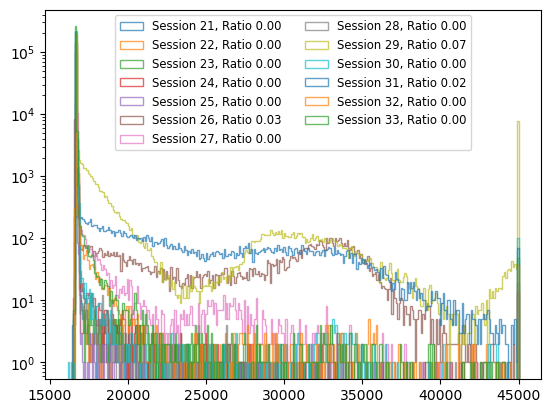

In [7]:
plt.close('all')
for s_id in framew_beh.index.unique('session_id'):
    if not (s_id >20):
        continue
    session_data = framew_beh[framew_beh.index.get_level_values('session_id') == s_id]
    
    frame_lengths = np.diff(session_data.frame_pc_timestamp)
    ratio = (frame_lengths>30_000).sum() / frame_lengths.size
    frame_lengths = np.clip(frame_lengths, 0, 45_000)
    plt.hist(frame_lengths  , bins=300, label=f'Session {s_id}, Ratio {ratio:.2f}', histtype='step', alpha=0.7)
    plt.yscale("log")
plt.legend(fontsize='small', ncol=2)
plt.show()

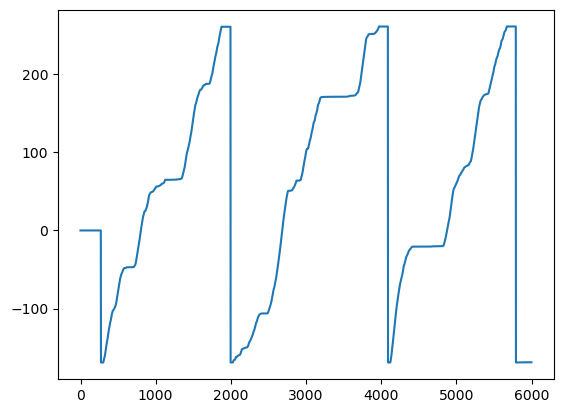

In [11]:
plt.plot(session_data.frame_position.iloc[:6000].values)

(1604, 135) 1.0
(1973, 135) 2.0
(1581, 135) 3.0
(2077, 135) 4.0
(2251, 135) 5.0
(1688, 135) 6.0
(1247, 135) 7.0
(1389, 135) 8.0
(2885, 135) 9.0
(1834, 135) 10.0
(2156, 135) 11.0
(1285, 135) 12.0


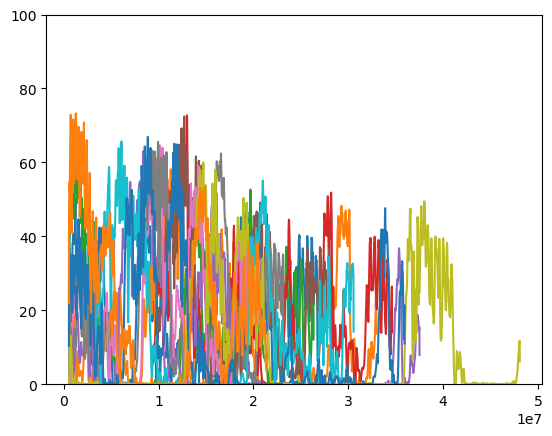

In [12]:
plt.close('all')
session_beh = framew_beh.xs(s_id, level='session_id')
for trial in session_beh['trial_id'].unique():
    if trial == -1:
        continue
    trial_d = session_beh[session_beh['trial_id'] == trial]
    print(trial_d.shape, trial)
    t_start = trial_d['frame_pc_timestamp'].iloc[0]
    # t_end = trial_d['frame_pc_timestamp'].iloc[-1]
    positions = trial_d[['frame_position']]
    velocities = trial_d[['frame_velocity']]
    time = trial_d['frame_pc_timestamp'] - t_start
    # print(positions)
    # print(time)
    
    # draw line
    # plt.plot(time, positions, label=f'Trial {trial}')
    plt.plot(time, velocities, label=f'Trial {trial}')
    if trial >=12:
        break
# plt.xlim(0, 20_000_000)
plt.ylim(0, 100)
plt.show()